In [1]:
import numpy as np
from utils.config import load_config, Configuration
import pandas as pd

config = load_config("config.yaml")

In [2]:

subj = 1
mask_value = 1



data = np.load(f"data/mds_dir/subj_{subj:02d}/mask_{mask_value}_averaged_mds.npy")
metadata = np.load(f"data/rdm_dir/subj_{subj:02d}/metadata.npy")

fitted_voxels_df = pd.read_excel(f"data/gaussian_results/subj{subj:02d}/fitted_voxels_mask_{mask_value}.xlsx", index_col=0)
fitted_voxels_df = fitted_voxels_df.sort_values(by='sigma')

print(len(metadata))

print(np.load(f"data/mds_dir/subj_{subj:02d}/{subj}_mask20_mds_sample0.npy").shape)

85
(85, 2)


In [3]:
fitted_voxels_df

,x0,y0,sigma,slope,intercept
253532,-1.048718,1.048215,0.010017,0.010213,0.318560
288805,1.045678,1.036655,0.010019,1.274309,0.291850
29977,1.043997,-1.045166,0.010029,0.034433,0.784739
274165,-0.154315,-0.386333,0.010030,2.910193,-0.099229
59923,0.489168,0.350692,0.010043,2.334474,-0.057102
...,...,...,...,...,...
80435,1.049998,0.672719,33.447694,131.844116,-131.671914
70595,-1.050000,-0.564580,35.535599,74.784926,-74.644324
43436,0.392518,-0.964550,37.617821,201.058107,-200.960171
58580,0.766904,-0.664054,41.563877,67.258041,-67.196330


In [4]:
import matplotlib.pyplot as plt

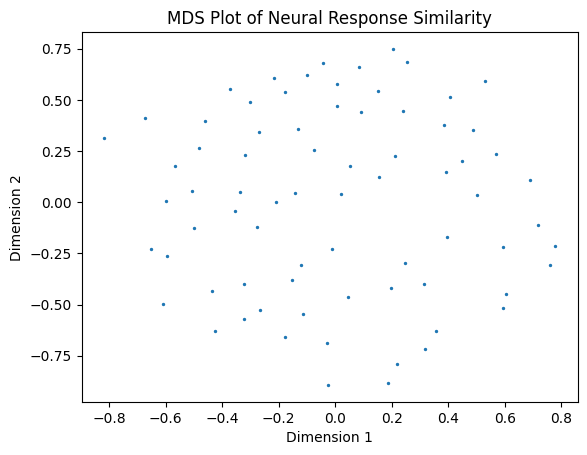

In [5]:
# Plot the results
plt.scatter(data[:, 0], data[:, 1], s=2)
plt.title("MDS Plot of Neural Response Similarity")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

In [6]:
import os
from PIL import Image
images = [Image.open(os.path.join(config.images_target_dir, f"{i}.jpg")) for i in metadata]
titles = [f"{i}" for i in metadata]


In [7]:

# Create and run the app
images = [os.path.join(config.images_target_dir, f"{i}.jpg") for i in metadata]


In [8]:
from dash import Dash, html, dcc
import plotly.graph_objects as go
from dash.dependencies import Input, Output, State
from dash import callback_context  # Import callback context

from PIL import Image
import base64
import io
import json
import os
import numpy as np



def create_interactive_image_scatter_dash(data, images, titles=None, width=1500, height=1500):
    """
    Create an interactive scatter plot using Dash where images are displayed at coordinates.
    
    Parameters:
    data: numpy array of shape (n_samples, 2) containing x,y coordinates
    images: list of PIL Images or paths to image files
    titles: optional list of titles for each point
    """

    # Load face detection results
    with open(config.face_detection_results_path, "r") as f:
        face_detection_data = json.load(f)

    image_strings = []
    thumbnail_size = (200, 200)  # Size of images on the plot

    for img in images:
        file_basename = os.path.basename(img)
        detection_bbox = [e for e in face_detection_data if e["file_name"] == file_basename][0]["detection"][0]
        if isinstance(img, str):  # If it's a path
            img = Image.open(img)
        img = img.crop((detection_bbox[0], detection_bbox[1], detection_bbox[2], detection_bbox[3]))
        
        # Create thumbnails
        img_thumb = img.copy()
        img_thumb.thumbnail(thumbnail_size)
        img_full = img.resize((400, 400))
        
        # Convert images to base64
        thumb_buffered = io.BytesIO()
        img_thumb.save(thumb_buffered, format="PNG")
        thumb_str = base64.b64encode(thumb_buffered.getvalue()).decode()

        full_buffered = io.BytesIO()
        img_full.save(full_buffered, format="PNG")
        full_str = base64.b64encode(full_buffered.getvalue()).decode()

        image_strings.append({'thumbnail': thumb_str, 'full': full_str})

    # Create Dash app
    app = Dash(__name__)

    # Define heatmap grid
    grid_size = 500
    x_range = np.linspace(-1, 1, grid_size)
    y_range = np.linspace(-1, 1, grid_size)
    X, Y = np.meshgrid(x_range, y_range)

    # Function to generate Gaussian heatmap
    def get_gaussian_heatmap(x0, y0, sigma):
        Z = (1 / (2 * np.pi * sigma**2)) * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))
        return Z / np.max(Z)  # Normalize

    # Initialize figure
    fig = go.Figure()

    # Add initial heatmap
    
    row = fitted_voxels_df.iloc[0]
        
    voxel_i = row.name
    x0, y0, sigma = row[['x0', 'y0', 'sigma']]


    Z = get_gaussian_heatmap(x0, y0, sigma)
    fig.add_trace(go.Heatmap(
        z=Z, x=x_range, y=y_range,
        colorscale='Reds',
        opacity=0.4,
        showscale=False
    ))

    # Add invisible scatter points to maintain plot range
    fig.add_trace(go.Scatter(
        x=[-1, 1], y=[-1, 1], mode='markers',
        marker=dict(size=0, opacity=0), hoverinfo='skip'
    ))

    # Add data points as invisible markers
    fig.add_trace(go.Scatter(
        x=data[:, 0], y=data[:, 1], mode='markers',
        marker=dict(size=0, opacity=0), hoverinfo='skip'
    ))

    # Add images as layout shapes
    for i, (coords, img_data) in enumerate(zip(data, image_strings)):
        fig.add_layout_image(dict(
            source=f'data:image/png;base64,{img_data["thumbnail"]}',
            x=coords[0], y=coords[1],
            xref="x", yref="y",
            sizex=0.1, sizey=0.1,
            xanchor="center", yanchor="middle",
            layer="above"
        ))

    # Update layout
    fig.update_layout(
        title="MDS Plot of Neural Response Similarity",
        xaxis_title="Dimension 1",
        yaxis_title="Dimension 2",
        hovermode='closest',
        xaxis=dict(range=[-1, 1], fixedrange=True, constrain='domain'),
        yaxis=dict(range=[-1, 1], fixedrange=True, scaleanchor="x", scaleratio=1, constrain='domain'),
        width=width, height=height, showlegend=False
    )

    # Define app layout with an information panel
    app.layout = html.Div([
        dcc.Graph(id='scatter-plot', figure=fig, config={
            'doubleClick': 'reset',
            'scrollZoom': False,
            'displayModeBar': True,
            'modeBarButtonsToRemove': ['zoom', 'pan', 'select', 'lasso2d']
        }),
        html.Div(id='image-container', style={'textAlign': 'center', 'marginTop': '20px'}),
        html.Div(id='info-panel', style={'textAlign': 'center', 'fontSize': '20px', 'marginBottom': '10px'}),
        html.Div([
            html.Button("Previous", id="prev-btn", n_clicks=0),
            html.Button("Next", id="next-btn", n_clicks=0),
        ], style={'textAlign': 'center', 'marginTop': '20px'}),
        dcc.Store(id='index-store', data=0)
    ])

    # Callback to update heatmap and information panel
    @app.callback(
        [Output('scatter-plot', 'figure'),
         Output('index-store', 'data'),
         Output('info-panel', 'children')],
        [Input('prev-btn', 'n_clicks'),
         Input('next-btn', 'n_clicks')],
        [State('index-store', 'data')]
    )
    def update_distribution(prev_clicks, next_clicks, current_index):
        if current_index is None:
            current_index = 0


        # new_index = (current_index + (next_clicks - prev_clicks)) % len(distributions)
        # print(f"{new_index=}")


        # Identify which button was clicked
        ctx = callback_context
        if not ctx.triggered:
            return fig, current_index, "Click a button to change distribution."

        button_id = ctx.triggered[0]['prop_id'].split('.')[0]  # Get button ID

        # Update index based on the clicked button
        if button_id == "prev-btn":
            new_index = (current_index - 1) % len(fitted_voxels_df.index)
        elif button_id == "next-btn":
            new_index = (current_index + 1) % len(fitted_voxels_df.index)
        else:
            new_index = current_index  # No valid button pressed


        # Get new distribution
        row = fitted_voxels_df.iloc[new_index]
        
        voxel_i = row.name
        x0, y0, sigma = row[['x0', 'y0', 'sigma']]
        Z = get_gaussian_heatmap(x0, y0, sigma)

        # Create a copy of the figure and update heatmap
        updated_fig = go.Figure(fig)
        updated_fig.data[0].z = Z  # Update heatmap only

        info_text = f"Index: {voxel_i} | Mean: ({x0:.2f}, {y0:.2f}) | Sigma: {sigma:.2f}"
        return updated_fig, new_index, info_text

    # Callback to display larger image when clicking on a point
    @app.callback(
        Output('image-container', 'children'),
        Input('scatter-plot', 'clickData')
    )
    def display_image(clickData):
        if clickData is None:
            return html.Div("Click an image to view it larger")

        point_index = clickData['points'][0]['pointIndex']
        img_src = f'data:image/png;base64,{image_strings[point_index]["full"]}'
        title = titles[point_index] if titles else f"Point {point_index}"

        return html.Div([
            html.H4(title),
            html.Img(src=img_src, style={'maxWidth': '400px'})
        ])

    return app

In [9]:
app = create_interactive_image_scatter_dash(data, images, width=1000, height=1000)
app.run_server(debug=True, port=8050)